In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import re 

In [2]:
### Ler o documento
def read_file(path):
    with open(path, 'r') as archive:
        lines = archive.read().splitlines()
        lines.pop(0)
        return lines
        
### Encontrar as linhas de cada linha atômica
def new_specline(self):
    return "/TYPE" in self and "A" in self

def get_parameters(self):
    temp = []
    densit = []

    idx = 0
    length_data = len(self)
   
    while idx < length_data:
        row = self[idx]
        
        if new_specline(row):
            match = re.search(r"(\d+\.\d+)A",row)
            match_type = re.search(r'/TYPE\s=\s(\S+)',row)
            
            if match and match.group(1) == "33.8" and match_type.group(1) == "EXCIT":
                idx += 1
                
                for _ in range(3):
                    row_data = self[idx]
                    # Separa os valores tratadas pela notação científica do FORTRAN (D -> E):
                    for num in row_data.replace('D', 'E').split():
                        densit.append(float(num))
        
                    idx += 1
            if match and match.group(1) == "33.8" and match_type.group(1) == "RECOM":  
                idx += 4
                
                for _ in range(3):
                    row_data = self[idx]
                    # Separa os valores tratadas pela notação científica do FORTRAN (D -> E):
                    for num in row_data.replace('D', 'E').split():
                        temp.append(float(num))
        
                    idx += 1
        idx += 1
    
    return temp, densit
    
### Gerar o dicionário com as PECS, TRANSIÇÕES e COMPRIMENTOS DE ONDA para cada comprimento de onda
def pec_matrix_creation(self):
    dic_excit = {} 
    dic_recom = {}
    temp, density = get_parameters(self)
    # Indice no qual iremos iterar
    idx = 0
    length_data = len(self)

    ### Iterar sobre todas as linhas
    while idx < length_data:
        
        row = self[idx]
        
        ### Checar se linha é comprimento de onda novo (True se sim e False se não)
        if new_specline(row): 
            match_type = re.search(r'/TYPE\s=\s(\S+)',row) # Encontra o tipo de transição
            
            ### Se o comprimento de onda estiver ali pula as linhas até atingir as pecs
            if match_type.group(1) == "EXCIT":
                match = re.search(r"(\d+\.\d+)A",row) ### Encontra o comprimento de onda
                wave_value = float(match.group(1)) # Pega o comprimento de onda em [A]
                
                ###Pular as lihas
                idx += 7
                
                ### Define as listas de valores e a lista que servirá como matriz
                values = []
                
                ### Itera sobre os blocos de 3 em 3 linhas para criar as linhas:
                for _ in range(int(3 * 24)):
                    if idx < length_data:
                        row_data = self[idx]
                        
                        # Separa os valores tratadas pela notação científica do FORTRAN (D -> E):
                        for num in row_data.replace('D', 'E').split():
                            values.append(float(num))
                
                        idx += 1
                        
                pec_for_wavelength = np.array(values).reshape(24, 21)   
                
                ### Adiciona as matrizes para cada comprimento de onda dentro da matriz pec
                dic_excit[wave_value] = {
                    "PEC": pec_for_wavelength,
                    "temp": temp,
                    "density": density
                }
                ### Continue apenas para não bugar o loop? (gepeto ajudou)
                continue
                
            if match_type.group(1) == "RECOM":
                match = re.search(r"(\d+\.\d+)A",row) ### Encontra o comprimento de onda
                wave_value = float(match.group(1)) # Pega o comprimento de onda em [A]
                
                ###Pular as lihas
                idx += 7
                
                ### Define as listas de valores e a lista que servirá como matriz
                values = []
                
                ### Itera sobre os blocos de 3 em 3 linhas para criar as linhas:
                for _ in range(int(3 * 24)):
                    if idx < length_data:
                        row_data = self[idx]
                        
                        # Separa os valores tratadas pela notação científica do FORTRAN (D -> E):
                        for num in row_data.replace('D', 'E').split():
                            values.append(float(num))
                
                        idx += 1
                        
                pec_for_wavelength = np.array(values).reshape(24, 21)   
                
                ### Adiciona as matrizes para cada comprimento de onda dentro da matriz pec
                dic_recom[wave_value] = {
                    "PEC": pec_for_wavelength,
                    "temp": temp,
                    "density": density
                }
                                             
                ### Continue apenas para não bugar o loop? (gepeto ajudou)
                continue
                
        ### Dicionário contendo os comprimentos de onda, o tipo de transição e as matrizes correspondentes)                       
        idx += 1
    
    ### Retorna um dicionário com matrizes de dimensão (24x21) - (N_densidades x N_temperaturas)
    return dic_excit, dic_recom


def get_pec(excit, recom,  wavelength, ne, te, kind = None, n0 = None, permit_extrapolation = False):
    temp_e = np.log(excit[wavelength]["temp"])
    dens_e = np.log(excit[wavelength]["density"])

    if (min(dens_e) <= np.log(ne) <= max(dens_e)) and (min(temp_e)<= np.log(te) <= max(temp_e)):
        if kind == "EXCIT":
            pec_discret = excit[wavelength]["PEC"]
            interp_pec = sp.interpolate.RegularGridInterpolator((dens_e, temp_e), pec_discret, method = "linear", bounds_error = True, fill_value = permit_extrapolation)
            return interp_pec((np.log(ne), np.log(te)))
        if kind == "RECOM":
            pec_discret = recom[wavelength]["PEC"]
            interp_pec = sp.interpolate.RegularGridInterpolator((dens_e, temp_e), pec_discret, method = "linear", bounds_error = True, fill_value = permit_extrapolation)
            return interp_pec((np.log(ne), np.log(te)))
        else:
            return print("Please specify the kind of transition: 'EXCIT' or 'RECOM'")
    else:
        return print("The density and temperature values are out of the range of the data. Please provide values within the range of the data.")
    

In [3]:
a = read_file("pecs96.dat")
excit, recom = pec_matrix_creation(a)

In [23]:
te = np.linspace(5.0, 1.0e4, num = 1000)
ne = 1.0e14

temp_e = excit[5292.7]["temp"]
dens_e = excit[5292.7]["density"]

In [24]:
pec_excit = []
pec_recomb = []

for i in range(len(te)):
    pec_excit.append(get_pec(excit, recom, wavelength = 5292.7, ne = ne, te = te[i], kind = "EXCIT", permit_extrapolation = True))
    pec_recomb.append(get_pec(excit, recom, wavelength = 5292.7, ne = ne, te = te[i], kind = "RECOM", permit_extrapolation = True))

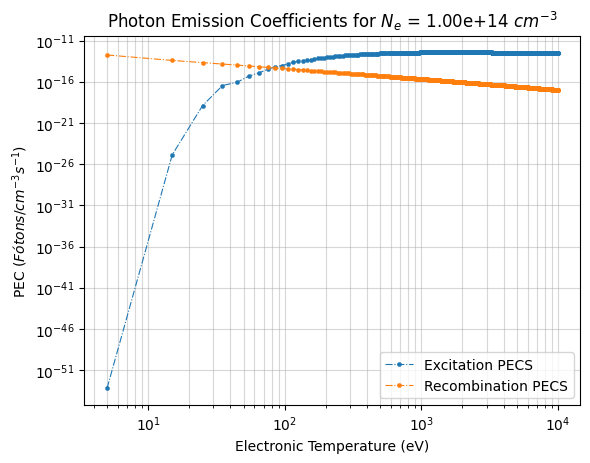

In [37]:
plt.figure()
plt.loglog(te, pec_excit, label = "Excitation PECS", lw = .8, ls = '-.', marker = '.', mew = .3)
plt.loglog(te, pec_recomb,  label = "Recombination PECS", lw = .8, ls = '-.', marker = '.', mew = .3)
plt.title(f"Photon Emission Coefficients for $N_e$ = {ne:.2e} $cm^{{-3}}$")
plt.xlabel("Electronic Temperature (eV)")
plt.ylabel("PEC $(Fótons/cm^{-3}s^{-1})$")
plt.grid(True, which="both", alpha = .5)
plt.legend()
plt.savefig("PEC_Result00.png")
plt.show()

In [ ]:
# Teste de sanidade 
# Teste de interpolação nodal

# PEC OBTIDA ATRAVÉS DO INTERPOLADOR
# Vê se ela bate com a matriz correspondente
matriz_pec_nós = recom[5292.7]["PEC"]
pec_interpolador = []

idx = 0
while idx < len(dens_e):
    pec_per_ne = []
    for i in range(len(temp_e)):
        pec_per_ne.append(get_pec(excit, recom, wavelength = 5292.7, ne = ne[idx], te = temp_e[i], kind = "RECOM", permit_extrapolation = True))
    pec_interpolador.append(pec_per_ne)
    idx += 1

matriz_pec_interpolador = np.array(pec_interpolador).reshape(24, 21)


errors_per_density = []
for i in range(len(dens_e)):
    error = np.abs(matriz_pec_interpolador[i] - matriz_pec_nós[i]).max()
    errors_per_density.append(error)

In [ ]:
# Verificação visual:
# for i in range(len(dens_e)):
#     if ( 0.9e12 < dens_e[i] < 1e14):
#         plt.scatter(temp_e, matriz_pec_interpolador[i], marker = "^", label= f"{dens_e[i]:.2e}")
#         plt.scatter(temp_e, matriz_pec_nós[i],marker = "o")
plt.errorbar(temp_e, matriz_pec_nós[13], marker = "o", label = f"Nós")
plt.errorbar(temp_e, matriz_pec_interpolador[13], xerr = errors_per_density[18], marker = "^", label= f"Valores calculados")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Electronic Temperature (eV)")
plt.ylabel("PEC $(Fótons/cm^{-3}s^{-1})$")
plt.title("Plot error Nodal")
plt.grid(True, which="both", alpha = .5)
plt.legend()
plt.savefig("Error_nodal.png")
plt.show()


In [ ]:
dic_error = {
    "Temperatura": temp_e,
    "Pecs_tabela_ADAS": matriz_pec_nós[13],
    "Pecs_calculadas": matriz_pec_interpolador[13],
    "Error modal (Médio)": errors_per_density[13],
}

dic_error = {
    "densidade": dens_e,
    "Error Modal": errors_per_density,
}
df = pd.DataFrame(dic_error)

In [ ]:
print(df.to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.2e}".format,
                  ))

In [ ]:
f"{dens_e[13]:.2e}"

In [ ]:
matriz_pec_nós[0], matriz_pec_interpolador[0]